In [6]:
# This script just prints out the graphics diagram used for Figure 1A and B. We use a straightforward approach
# to computing CKA and cosine similarity here, since we're only operating over a subset of the validation set.
# For final CKA and cosine similarity computations we use a more iterative approach to save memory when evaluating
# the full validation set.

import os
import matplotlib.pyplot as plt
import numpy as np

# for computing activations
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# for MDS
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import ConnectionPatch
from scipy.linalg import orthogonal_procrustes

# utilities
from pathlib import Path
import json

#file_path = Path(os.path.dirname(os.path.realpath(__file__)))
file_path=Path('/home/bogdan/MyDocuments/canlab/hcp_hyperalignment/papers/git_paper/scripts')
repo_root = file_path / '..'

config_path = repo_root / 'config.json'

with open(config_path) as f:
    config = json.load(f)
    
ST_BASE_FS = repo_root / 'resources' / 'ann_data'
os.environ['ST_BASE_FS'] = str(ST_BASE_FS)

'''
This script uses GPU computing to evaluate recomputed models. If you have torch vesion mismatches or CUDA version
mismatches with the original models you may get issues related to "deserializing" models. If that's the case, 
disable GPU computing by hiding your CUDA devices here and modify load_model_from_checkpoint in 
TDANN/demo/src/model.py to invoke torch.load(checkpoint_path) with the map_locaiton=torhc.device('cpu') option.
'''
#os.environ['CUDA_VISIBLE_DEVICES'] = "" # this is due to old torch version that's not compatible with my CUDA

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == 'cpu':
    warnings.warn('GPU not autodetected.')
else:
    print('Successfully found GPU')

TDANN_path = Path(config['TDANN_repo_path'])
os.chdir(str(TDANN_path)) # this is the main repo code, which we need for loading old model weights

import sys
sys.path.append(str(TDANN_path / 'demo')) # we reuse some code from here for loading old model weights
from src.positions import NetworkPositions
from src.model import load_model_from_checkpoint, LAYERS
from src.data import load_image, create_dataloader
from src.features import FeatureExtractor

# These are the pretrained positions, based on sine grating sweeps, copied from the neuroAI repo
positions_dir = os.path.join(repo_root, 'resources/ann_data/positions/simclr_spatial_resnet18_fuzzy_swappedon_SineGrating2019_lw0/resnet18_retinotopic_init_fuzzy_swappedon_SineGrating2019_NBVER2')

# Load model checkpoints
from pathlib import Path

CKPT_ROOT = Path(ST_BASE_FS) / "tdann" / "checkpoints"

def tdann_ckpt_path_for_seed(seed: int, spatial = True) -> Path:
    """Return path to model_final_checkpoint for a given TDANN seed (0–4)."""

    '''
    subdir = "simclr_spatial_resnet18_swappedon_SineGrating2019_isoswap_3_"

    if not spatial:
        subdir = subdir + "lw0_"

    if not spatial or seed != 0:
        subdir = subdir + f"seed_{seed}_"

    if spatial:
        subdir = subdir + "linear_eval_checkpoints"
        chkpt = CKPT_ROOT / "linear_eval" / subdir / "model_final_checkpoint_phase27.torch"
    else:
        subdir = subdir + "checkpoints"
        chkpt = CKPT_ROOT / subdir / "model_final_checkpoint_phase199.torch"
    '''


    CKPT_ROOT = repo_root / 'resources' / 'ann_data' / 'checkpoints'
    subdir = f"spatial_resnet18_swappedon_SineGrating2019_isoswap_3_seed_{seed}"

    if spatial:
        subdir = 'simclr_' + subdir
        chkpt = CKPT_ROOT / subdir / "model_final_checkpoint_phase199.torch"
    else:
        subdir = 'simclr_non' + subdir
        chkpt = CKPT_ROOT / subdir / "model_final_checkpoint_phase199.torch"

    return chkpt

seeds = {'Spatial': config['ann_dyad']+np.array([0,7]), 
    'Nonspatial': config['ann_dyad']+np.array([0,7])}
tdann_models = {'Spatial': {}, 'Nonspatial': {}}

for spatial in tdann_models.keys():    
    for seed in seeds[spatial]:
        if spatial == 'Spatial':
            ckpt_path = tdann_ckpt_path_for_seed(seed)
        elif spatial == 'Nonspatial':
            ckpt_path = tdann_ckpt_path_for_seed(seed, spatial=False)
        else:
            raise ValueError(f'Expected: Spatial or Nonspatial, but got {spatial}')
        print(f"Loading TDANN seed {seed} from {ckpt_path}")
        model = load_model_from_checkpoint(str(ckpt_path))  # uses demo/src/model.py
        model.eval()
        tdann_models[spatial][f"seed{seed}"] = model
    print(list(tdann_models[spatial].keys()))


# load testing data
imgnet_train_mean = [0.485, 0.456, 0.406]
imgnet_train_std = [0.229, 0.224, 0.225]

imgnet_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imgnet_train_mean,
        std=imgnet_train_std),
])

dataset = datasets.ImageNet(root=config['imagenet_path'], split='val', transform=imgnet_transforms)


Successfully found GPU
Loading TDANN seed 3 from /home/bogdan/MyDocuments/canlab/hcp_hyperalignment/papers/git_paper/scripts/../resources/ann_data/checkpoints/simclr_spatial_resnet18_swappedon_SineGrating2019_isoswap_3_seed_3/model_final_checkpoint_phase199.torch
Loading TDANN seed 10 from /home/bogdan/MyDocuments/canlab/hcp_hyperalignment/papers/git_paper/scripts/../resources/ann_data/checkpoints/simclr_spatial_resnet18_swappedon_SineGrating2019_isoswap_3_seed_10/model_final_checkpoint_phase199.torch
['seed3', 'seed10']
Loading TDANN seed 3 from /home/bogdan/MyDocuments/canlab/hcp_hyperalignment/papers/git_paper/scripts/../resources/ann_data/checkpoints/simclr_nonspatial_resnet18_swappedon_SineGrating2019_isoswap_3_seed_3/model_final_checkpoint_phase199.torch
Loading TDANN seed 10 from /home/bogdan/MyDocuments/canlab/hcp_hyperalignment/papers/git_paper/scripts/../resources/ann_data/checkpoints/simclr_nonspatial_resnet18_swappedon_SineGrating2019_isoswap_3_seed_10/model_final_checkpoin

In [7]:
'''
Manage inputs. Here we extract a random sample to use for MDS plots and examples in Figures 1A and 1B

When I first ran this script I was using shuffled dataloaders and batches of 50, with 
a fixed seed, but it seems that shuffle order varies by torchvision version, despite the fixed seed.
Consequently, I've switched to a non-shuffled dataloader, and am hard coding the original batches, in
the order they were originally listed for more robust reproducability.
'''

bs = 50
dataloader = DataLoader(dataset, batch_size=200, num_workers=8, pin_memory=True, shuffle=False)

# target stimuli. 
original_batch = np.loadtxt(repo_root / 'resources' / 'ann_data' / 'shuffled_imagenet_subset_indices.csv', dtype=int)

# create a new dataloader that subsets the specific indices we originally used
subset = Subset(dataset, original_batch.tolist())
subset_loader = DataLoader(subset, batch_size=50, shuffle=False)

# get inputs we'll use for MDS plots
inputs, labels = next(iter(subset_loader))

In [8]:
# extract features from layers, following examples of the Margalit 2024 figures
target_layers = [
    'layer1.0',
    'layer1.1',
    'layer2.0',
    'layer2.1',
    'layer3.0',
    'layer3.1',
    'layer4.0',
    'layer4.1',
]

def extract_model_features(models: dict, dataloader, layers, n_batches: int = 20):
    """
    models: dict name -> nn.Module
    returns: dict[name][layer] = np.array of shape (n_images, n_units)
    """
    all_feats = {}
    for name, model in models.items():
        print(f"\n=== Extracting features for {name} ===")

        # for consistent shuffle across seeds
        torch.manual_seed(0)

        extractor = FeatureExtractor(
            dataloader,
            n_batches=n_batches,
            vectorize=False,    # (batch, n_channels, n, m), don't flatten here so we can shuffle channels for null
            verbose=True,
        )
        feats, inputs, labels = extractor.extract_features(
            model.to(DEVICE),
            layers,
            return_inputs_and_labels=True,
        )
        # feats is already dict[layer] -> (n_images, n_units) as np.ndarray
        all_feats[name] = feats
    return all_feats, inputs, labels

# Example: use first ~n_batches * bs samples from ImageNet val
subset_loader = DataLoader(subset, batch_size=32, shuffle=False)
n_batches = 20  # adjust as you like
tdann_feats = {k: [] for k in tdann_models}
inputs = {k: [] for k in tdann_models}
labels = {k: [] for k in tdann_models}
for spatial in tdann_models.keys():
    tdann_feats[spatial], inputs[spatial], labels[spatial] = extract_model_features(
        tdann_models[spatial], subset_loader, target_layers, n_batches=n_batches
    )




=== Extracting features for seed3 ===


batch: 100%|████████████████████████████████████| 20/20 [00:07<00:00,  2.80it/s]



=== Extracting features for seed10 ===


batch: 100%|████████████████████████████████████| 20/20 [00:04<00:00,  4.43it/s]



=== Extracting features for seed3 ===


batch: 100%|████████████████████████████████████| 20/20 [00:04<00:00,  4.06it/s]



=== Extracting features for seed10 ===


batch: 100%|████████████████████████████████████| 20/20 [00:04<00:00,  4.21it/s]


In [9]:
# Evaluate model similarities using simple algorithms

import itertools
import pandas as pd

def linear_cka(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Linear CKA between two feature matrices X and Y.
    X, Y: (n_samples, n_features)
    """
    # Center in sample space
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    # Gram matrices
    K = X @ X.T
    L = Y @ Y.T

    # HSIC-style normalization
    hsic = (K * L).sum()
    norm_x = (K * K).sum() ** 0.5
    norm_y = (L * L).sum() ** 0.5
    return float(hsic / (norm_x * norm_y + 1e-12))


def mean_cosine_similarity(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Mean cosine similarity, computed per sample, between two representations.
    X, Y: (n_samples, n_features)
    """
    eps = 1e-8
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
    Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + eps)
    cos = (Xn * Yn).sum(axis=1)  # (n_samples,)
    return float(cos.mean())


def compare_two_models(feats_a, feats_b, layers, null=False):
    """
    feats_a, feats_b: dict[layer] -> (n_samples, n_units)
    Returns: dict[layer] = {"cka": ..., "cos": ...}
    """

    if null:
        rng = np.random.default_rng(0)

    metrics = {}
    for layer in layers:
        Xa = np.asarray(feats_a[layer])
        Xb = np.asarray(feats_b[layer])

        # Make sure we use same number of images
        n = min(Xa.shape[0], Xb.shape[0])
        Xa = Xa[:n].reshape(n,-1)
        Xb = Xb[:n]

        if null:
            # functional null (stimuli are mismatched, function is known to be different)
            idx = rng.permutation(Xb.shape[0])
            Xb_fxn_null = np.take(Xb, idx, axis=0).reshape(n,-1)
            cka_val = linear_cka(Xa, Xb_fxn_null)

            # topographic null (channels are mismatched, topographies are known to be different)
            # (note: by shuffling channels we don't affect the convolutional architecture)
            idx = rng.permutation(Xb.shape[1])
            Xb_spatial_null = np.take(Xb, idx, axis=1).reshape(n,-1)
            cos_val = mean_cosine_similarity(Xa, Xb_spatial_null)
        else:
            Xb = Xb.reshape(n,-1)
            cka_val = linear_cka(Xa, Xb)
            cos_val = mean_cosine_similarity(Xa, Xb)
        
        metrics[layer] = {"cka": cka_val, "cos": cos_val}
    return metrics

def pairwise_metrics_all_seeds(features_by_model, layers, null=False):
    model_names = list(features_by_model.keys())
    rows = []
    #for (m1, m2) in itertools.combinations(model_names, 2):
    
    n = 2*int(len(model_names)/2)
    for (m1, m2) in zip(model_names[:int(n/2)], model_names[int(n/2):]):
    #for (m1, m2) in zip(model_names[::2], model_names[1::2]):
        metrics = compare_two_models(features_by_model[m1], features_by_model[m2], layers, null=null)
        for layer in layers:
            rows.append({
                "model1": m1,
                "model2": m2,
                "layer": layer,
                "cos": metrics[layer]["cos"],
                "cka": metrics[layer]["cka"],
            })
    return pd.DataFrame(rows)


df = {k: [] for k in tdann_feats.keys()}
for spatial in tdann_feats.keys():
    df[spatial] = pairwise_metrics_all_seeds(tdann_feats[spatial], target_layers)
print(df['Spatial'].head(8))
print(df['Nonspatial'].head(8))


  model1  model2     layer       cos       cka
0  seed3  seed10  layer1.0  0.522026  0.939699
1  seed3  seed10  layer1.1  0.531856  0.906612
2  seed3  seed10  layer2.0  0.422963  0.918047
3  seed3  seed10  layer2.1  0.488498  0.906338
4  seed3  seed10  layer3.0  0.383234  0.903857
5  seed3  seed10  layer3.1  0.434702  0.913835
6  seed3  seed10  layer4.0  0.253696  0.873594
7  seed3  seed10  layer4.1  0.246255  0.778641
  model1  model2     layer       cos       cka
0  seed3  seed10  layer1.0  0.525242  0.910818
1  seed3  seed10  layer1.1  0.471262  0.955717
2  seed3  seed10  layer2.0  0.308409  0.982695
3  seed3  seed10  layer2.1  0.300751  0.988659
4  seed3  seed10  layer3.0  0.262095  0.987040
5  seed3  seed10  layer3.1  0.313410  0.982109
6  seed3  seed10  layer4.0  0.186541  0.968907
7  seed3  seed10  layer4.1  0.146648  0.951682


In [10]:
# load positions from each model layer
network_positions = NetworkPositions.load_from_dir(positions_dir)
net1 = 3
net2 = int(net1 + 7) # we expect 14 networks which we paired off 0->7, 1->8, 2->9, etc.

spatial_mdl1_feats = tdann_feats['Spatial'][f'seed{net1}']
spatial_mdl2_feats = tdann_feats['Spatial'][f'seed{net2}']

nonspatial_mdl1_feats = tdann_feats['Nonspatial'][f'seed{net1}']
nonspatial_mdl2_feats = tdann_feats['Nonspatial'][f'seed{net2}']

# show response magnitude in each layer
def plot_layers(mdls, mdl_name, layers=LAYERS, stim=151, img_size=(4,4), title=False, s=1.5):
    n_layers = len(layers)
    n_mdls = len(mdls)
    fig = plt.figure(figsize=img_size)
    gs = fig.add_gridspec(
        len(mdls), n_layers,
        width_ratios=[1]*n_layers,
        left=0.1,
        right=0.95,
        bottom=0.18,
        top=0.82,
        wspace=0.35,
    )

    if isinstance(stim,int) or len(stim) < n_mdls:
        stim = [stim]*n_mdls

    axes2d = np.array([fig.add_subplot(gs[i]) for i in range(len(mdls)*n_layers)])
    axes = axes2d.reshape(len(mdls), n_layers)
    for i,(axes,mdl,name,s) in enumerate(zip(axes, mdls, mdl_name, stim)):        
        for j, (ax, layer) in enumerate(zip(axes, layers)):
            # coordinates is an N x 2 matrix of unit positions, in mm
            coordinates = network_positions.layer_positions[layer].coordinates
            
            # responses is an N-dimensional response vector from each layer
            responses = mdl[layer][s]
            
            # plot points, scaling by total size of the tissue in each layer
            extent = np.ptp(coordinates)
            ax.scatter(*coordinates.T, c=responses, cmap='afmhot', s=extent / 100)
            if title==True and i == 0:
                ax.set_title(layer)
            if j==0:
                ax.set_ylabel(name)

                # 1. Remove tick marks and tick labels (the numbers)
                ax.set_xticks([])
                ax.set_yticks([])

                # 2. Hide the spines (the axis lines/box)
                for spine in ax.spines.values():
                    spine.set_visible(False)
            else:
                ax.set_axis_off()
            ax.set_aspect('equal')
            ax.set_frame_on(False)

    return fig, axes

In [11]:
# import mapping from ImageNet indices to human readable labels
with open(Path(repo_root) / 'resources' / 'imagenet_labels_full.json', 'r') as file:
    json_data = json.load(file)
human_labels = {int(idx):content['label'] for idx, content in json_data.items()}

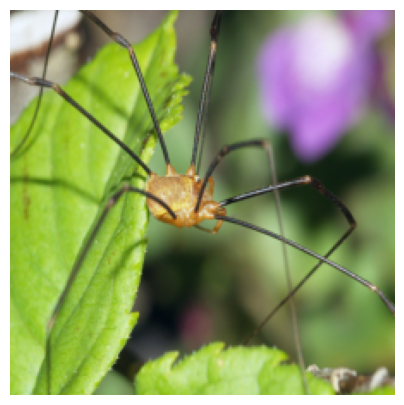

In [12]:
# Generate first example stimulus to use for Figure 1A
stim_ind = 5
imagenet_label = labels['Spatial'][stim_ind]
human_label = human_labels[imagenet_label].replace(' ','_')

# view the input image
# remove batch dim, and move channels to the end
raw = inputs['Spatial'][stim_ind].squeeze().transpose(1, 2, 0)

# normalize image to the range [0, 1]
normed = (raw - np.min(raw)) / np.ptp(raw)

# plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(normed)
ax.axis("off")
plt.savefig(os.path.join(repo_root, 'figures', 'figure1', 'panels', human_label + '.png'), 
    dpi=300, bbox_inches="tight", pad_inches=0.2)

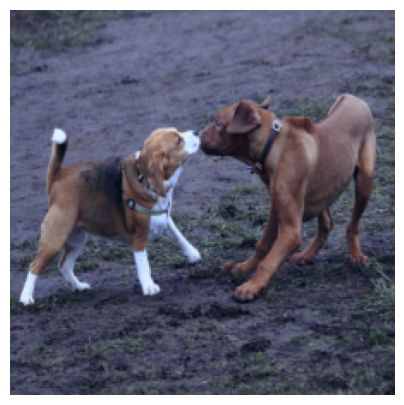

In [13]:
# Generate second example stimulus to use for Figure 1A
stim_ind = 47
imagenet_label = labels['Spatial'][stim_ind]
human_label = human_labels[imagenet_label].replace(' ','_')

# view the input image
# remove batch dim, and move channels to the end
raw = inputs['Spatial'][stim_ind].squeeze().transpose(1, 2, 0)

# normalize image to the range [0, 1]
normed = (raw - np.min(raw)) / np.ptp(raw)

# plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(normed)
ax.axis("off")
plt.savefig(os.path.join(repo_root, 'figures', 'figure1', 'panels', human_label + '.png'), 
    dpi=300, bbox_inches="tight", pad_inches=0.2)

In [28]:
np.linspace(0.1, 1.0, 256)

array([0.1       , 0.10352941, 0.10705882, 0.11058824, 0.11411765,
       0.11764706, 0.12117647, 0.12470588, 0.12823529, 0.13176471,
       0.13529412, 0.13882353, 0.14235294, 0.14588235, 0.14941176,
       0.15294118, 0.15647059, 0.16      , 0.16352941, 0.16705882,
       0.17058824, 0.17411765, 0.17764706, 0.18117647, 0.18470588,
       0.18823529, 0.19176471, 0.19529412, 0.19882353, 0.20235294,
       0.20588235, 0.20941176, 0.21294118, 0.21647059, 0.22      ,
       0.22352941, 0.22705882, 0.23058824, 0.23411765, 0.23764706,
       0.24117647, 0.24470588, 0.24823529, 0.25176471, 0.25529412,
       0.25882353, 0.26235294, 0.26588235, 0.26941176, 0.27294118,
       0.27647059, 0.28      , 0.28352941, 0.28705882, 0.29058824,
       0.29411765, 0.29764706, 0.30117647, 0.30470588, 0.30823529,
       0.31176471, 0.31529412, 0.31882353, 0.32235294, 0.32588235,
       0.32941176, 0.33294118, 0.33647059, 0.34      , 0.34352941,
       0.34705882, 0.35058824, 0.35411765, 0.35764706, 0.36117

In [31]:
from matplotlib.colors import LinearSegmentedColormap

# show response magnitude in each layer
def plot_layers(mdls, mdl_name, layers=LAYERS, stim=151, img_size=(4,4), fontsize=12, title=False, s=1.5):
    n_layers = len(layers)
    n_mdls = len(mdls)
    fig = plt.figure(figsize=img_size)
    gs = fig.add_gridspec(
        len(mdls), n_layers,
        width_ratios=[1]*n_layers,
        left=0.1,
        right=0.95,
        bottom=0.18,
        top=0.82,
        wspace=0.35,
    )

    # Skip the first 20% of afmhot (the black-to-dark-red part)
    afmhot_bright = LinearSegmentedColormap.from_list(
        'afmhot_bright', plt.cm.afmhot(np.linspace(0, 1.0, 256))
    )

    if isinstance(stim,int) or len(stim) < n_mdls:
        stim = [stim]*n_mdls

    axes2d = np.array([fig.add_subplot(gs[i]) for i in range(len(mdls)*n_layers)])
    axes = axes2d.reshape(len(mdls), n_layers)
    for i,(axes,mdl,name,s) in enumerate(zip(axes, mdls, mdl_name, stim)):        
        for j, (ax, layer) in enumerate(zip(axes, layers)):
            # coordinates is an N x 2 matrix of unit positions, in mm
            coordinates = network_positions.layer_positions[layer].coordinates
            
            # responses is an N-dimensional response vector from each layer
            responses = mdl[layer][s]
            vmin, vmax = np.percentile(responses,[0,99])
            
            # plot points, scaling by total size of the tissue in each layer
            extent = np.ptp(coordinates)
            ax.scatter(*coordinates.T, c=responses, cmap=afmhot_bright, s=extent / 100, vmax=vmax)
            if title==True and i == 0:
                ax.set_title(layer, fontsize=fontsize)
            if j==0:
                ax.set_ylabel(name, fontsize=fontsize)

                # 1. Remove tick marks and tick labels (the numbers)
                ax.set_xticks([])
                ax.set_yticks([])

                # 2. Hide the spines (the axis lines/box)
                for spine in ax.spines.values():
                    spine.set_visible(False)
            else:
                ax.set_axis_off()
            ax.set_aspect('equal')
            ax.set_frame_on(False)

    return fig, axes

In [15]:
network_positions = NetworkPositions.load_from_dir(positions_dir)

net1 = seeds['Spatial'][0]
net2 = seeds['Spatial'][1]

spatial_mdl1_feats = tdann_feats['Spatial'][f'seed{net1}']
spatial_mdl2_feats = tdann_feats['Spatial'][f'seed{net2}']

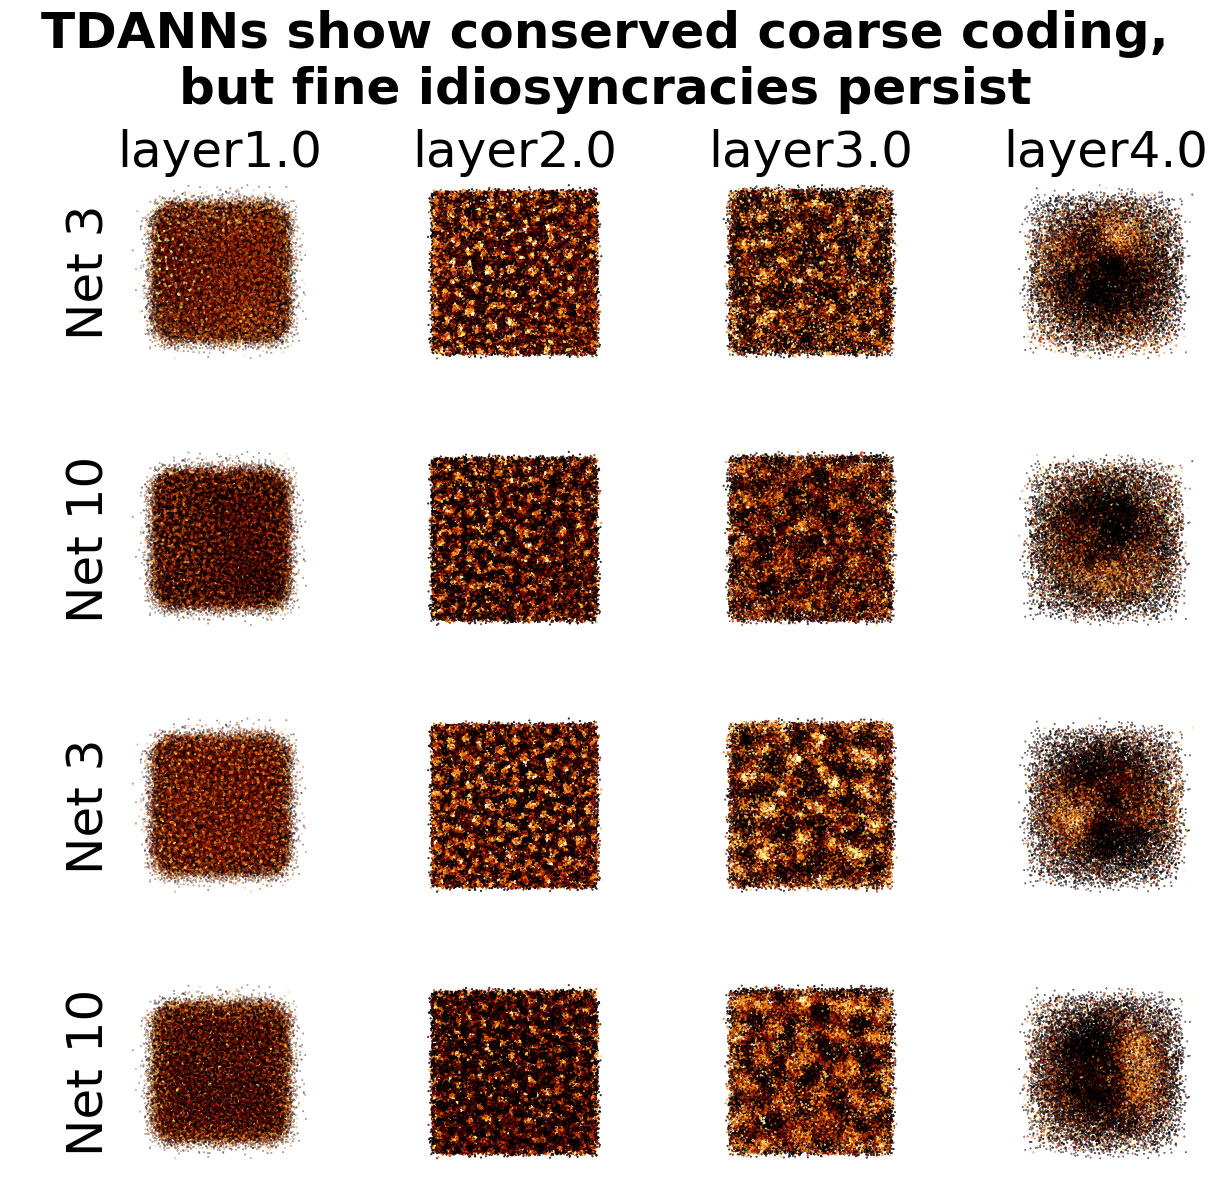

In [34]:
fig, axes = plot_layers([spatial_mdl1_feats, spatial_mdl2_feats, spatial_mdl1_feats, spatial_mdl2_feats], 
    [f'\nNet {net1}', f'\nNet {net2}', f'\nNet {net1}',f'\nNet {net2}'], 
    layers=['layer1.0', 'layer2.0', 'layer3.0', 'layer4.0'], stim=[5,5,47,47], title=True, 
    img_size=[12,12], fontsize=36, s=1)
fig.suptitle('TDANNs show conserved coarse coding,\nbut fine idiosyncracies persist',
    fontweight='bold', fontsize=36)
fig.set_layout_engine('constrained')
plt.savefig(os.path.join(repo_root, 'figures', 'figure1', 'panels', 'tdann_activations_compact.png'), 
    dpi=300, bbox_inches="tight", pad_inches=0.2)

In [12]:
# print layer by layer cosine similarities for stims 1 and 2
data = []
for stim in [5,47]:
    this_stim_data = []
    for layer in ['layer1.0', 'layer2.0', 'layer3.0', 'layer4.0']:
        x = spatial_mdl1_feats[layer][stim].ravel()
        y = spatial_mdl2_feats[layer][stim].ravel()
        x = x/np.sum(x**2)**0.5
        y = y/np.sum(y**2)**0.5
        theta = np.sum(x*y)
        this_stim_data.append(theta)
    data.append(this_stim_data)
print('Cosine similarities of responses to stim 1:')
print(data[0])
print('Cosine similarities of responses to stim 2:')
print(data[1])

Cosine similarities of responses to stim 1:
[0.5020491, 0.4124426, 0.4032636, 0.22672577]
Cosine similarities of responses to stim 2:
[0.55478406, 0.44406727, 0.39178184, 0.30700108]


In [13]:
def stimulus_to_hwc01(img_chw):
    """
    img_chw: torch tensor or numpy array shaped (C,H,W) or (H,W) or (H,W,C)
    Returns: (H,W,C) float in [0,1]
    """
    # torch -> numpy
    try:
        import torch
        if isinstance(img_chw, torch.Tensor):
            img = img_chw.detach().cpu().numpy()
        else:
            img = np.asarray(img_chw)
    except Exception:
        img = np.asarray(img_chw)

    # Make HWC
    if img.ndim == 2:  # H,W grayscale
        img = img[..., None]
    elif img.ndim == 3 and img.shape[0] in (1, 3):  # CHW -> HWC
        img = np.transpose(img, (1, 2, 0))
    elif img.ndim == 3 and img.shape[-1] in (1, 3):  # already HWC
        pass
    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")

    # Your notebook-style normalization to [0,1]
    img = img.astype(np.float32)
    img = (img - img.min()) / (np.ptp(img) + 1e-8)
    return img


def mds_coords_from_activations(X, metric="cosine", random_state=0, n_init=8, max_iter=2000):
    # torch -> numpy
    try:
        import torch
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
    except Exception:
        X = np.asarray(X)

    D = pairwise_distances(X, metric=metric)

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        metric=True,
        random_state=random_state,
        n_init=n_init,
        max_iter=max_iter,
        normalized_stress="auto",
    )
    coords = mds.fit_transform(D)
    return coords, D, mds.stress_


def procrustes_align(X_ref, X_move, *, allow_scaling=False, return_params=False):
    """
    Align X_move to X_ref using an orthogonal Procrustes transform (rotation/reflection),
    optionally with a global scale.

    Parameters
    ----------
    X_ref : (N,2) array
        Reference coordinates.
    X_move : (N,2) array
        Coordinates to be aligned to X_ref.
    allow_scaling : bool
        If True, allow a single global scale factor (in addition to rotation).
        If False, only rotation/reflection (no scaling).
    return_params : bool
        If True, returns (X_aligned, R, scale, mu_ref, mu_move)

    Returns
    -------
    X_aligned : (N,2) array
        X_move aligned into X_ref's frame.
    """
    X_ref = np.asarray(X_ref, float)
    X_move = np.asarray(X_move, float)

    # center
    mu_ref = X_ref.mean(axis=0, keepdims=True)
    mu_move = X_move.mean(axis=0, keepdims=True)
    A = X_ref - mu_ref
    B = X_move - mu_move

    # optional scaling pre-normalization (keeps things comparable)
    if allow_scaling:
        # Find best R and scale to map B -> A
        R, _ = orthogonal_procrustes(B, A)   # solves B @ R ~ A
        B_rot = B @ R
        scale = (A * B_rot).sum() / (B_rot * B_rot).sum()
        X_aligned = scale * B_rot + mu_ref
    else:
        R, _ = orthogonal_procrustes(B, A)
        scale = 1.0
        X_aligned = (B @ R) + mu_ref

    if return_params:
        return X_aligned, R, scale, mu_ref, mu_move
    return X_aligned


def plot_stimuli_on_mds(coords, inputs_images, ax=None, zoom=0.25, title="", ref_imgs=None, frame_color='aqua'):
    """
    coords: (N,2)
    inputs_images: something indexable like inputs['Spatial'] where inputs_images[i] is an image tensor/array
    """
    coords = np.asarray(coords, float)
    N = coords.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    else:
        fig = ax.figure

    ax.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.15)

    xmin, ymin = coords.min(axis=0)
    xmax, ymax = coords.max(axis=0)
    dx, dy = (xmax - xmin), (ymax - ymin)
    ax.set_xlim(xmin - 0.15 * dx, xmax + 0.15 * dx)
    ax.set_ylim(ymin - 0.15 * dy, ymax + 0.15 * dy)

    ab_handles = []
    for ind,img in enumerate(inputs_images):
        im = stimulus_to_hwc01(img)  # <-- THIS IS THE STIMULUS IMAGE
        oi = OffsetImage(im, zoom=zoom)
        if ref_imgs is not None and ind in ref_imgs:
            frameon=True
            zorder=ind+len(inputs_images)
            bboxprops=dict(edgecolor=frame_color,linewidth=2)
        else:
            frameon=False
            zorder=ind
            bboxprops={}
        ab = AnnotationBbox(oi, (coords[ind, 0], coords[ind, 1]), frameon=frameon, zorder=zorder, pad=0.0,
            bboxprops=bboxprops)
        ab.set_in_layout(False)
        ab_handles.append(ab)
        ax.add_artist(ab)

    # draw lines between framed boxes
    if ref_imgs is not None:
        for i,ind1 in enumerate(ref_imgs):
            for ind2 in ref_imgs[i:]:
                ab1 = ab_handles[ind1]
                ab2 = ab_handles[ind2]
                con = ConnectionPatch(
                    xyA=ab1.xy,      # (x, y) in data coords
                    xyB=ab2.xy,
                    coordsA="data",
                    coordsB="data",
                    axesA=ax,
                    axesB=ax,
                    color=frame_color,
                    linewidth=2.0,
                    zorder=len(inputs_images)+max(ind1,ind2),
                )
                ax.add_artist(con)

    ax.set_title(title, pad=20)
    #ax.set_xticks([]); ax.set_yticks([])
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    ax.grid(True, color='lightgray', linewidth=0.8, alpha=1)
    ax.set_axisbelow(True)  # put grid behind artists
    ax.tick_params(
        axis='both',
        which='both',
        length=0,          # remove tick marks
        labelbottom=False, # hide x labels
        labelleft=False    # hide y labels
    )
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_aspect("equal", adjustable="datalim")
    
    # set grid density
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    dx = (xmax - xmin)/5.5
    dy = (ymax - ymin)/5.5
        
    new_xticks = np.arange(
        xmin + dx/2,
        xmax,
        dx
    )

    new_yticks = np.arange(
        ymin + dy/2,
        ymax,
        dy
    )

    ax.set_xticks(new_xticks)
    ax.set_yticks(new_yticks)

    return fig, ax


def create_gridspec_axes(n,m,**kwargs):
    fig = plt.figure(**kwargs)
    gs = fig.add_gridspec(
        n,m,
        width_ratios=[1]*m,
        left=0.1,
        right=0.95,
        bottom=0.18,
        top=0.82,
        hspace=0.15,
    )

    ax = [fig.add_subplot(gs[i]) for i in range(n*m)]
    ax = np.array(ax).reshape(n,m)
    
    return fig, ax

In [14]:
# get MDS projections for first layer

spatial_key = "Spatial"
layer1 = "layer2.0"

seed_a = f"seed{net1}"
seed_b = f"seed{net2}"

Xa = tdann_feats[spatial_key][seed_a][layer1]   # (N,C,N,M)
Xb = tdann_feats[spatial_key][seed_b][layer1]   # (N,C,N,M)

Xa = Xa.reshape(Xa.shape[0],-1)
Xb = Xb.reshape(Xb.shape[0],-1)

coords_a, Da, stress_a = mds_coords_from_activations(Xa, metric="cosine", random_state=0)
coords_b, Db, stress_b = mds_coords_from_activations(Xb, metric="cosine", random_state=0)
coords_b = procrustes_align(coords_a, coords_b, allow_scaling=False)

print(f"MDS stress: {seed_a}={stress_a:.3g}, {seed_b}={stress_b:.3g}")

MDS stress: seed3=1.88e+03, seed10=1.1e+03


In [15]:
# get MDS projections for second layer

layer2 = "layer4.0"

Xc = tdann_feats[spatial_key][seed_a][layer2]   # (N,C,N,M)
Xd = tdann_feats[spatial_key][seed_b][layer2]   # (N,C,N,M)

Xc = Xc.reshape(Xa.shape[0],-1)
Xd = Xd.reshape(Xb.shape[0],-1)

coords_c, Dc, stress_c = mds_coords_from_activations(Xc, metric="cosine", random_state=0)
coords_d, Dd, stress_d = mds_coords_from_activations(Xd, metric="cosine", random_state=0)
coords_d = procrustes_align(coords_c, coords_d, allow_scaling=False)


print(f"MDS stress: {seed_a}={stress_a:.3g}, {seed_b}={stress_b:.3g}")

MDS stress: seed3=1.88e+03, seed10=1.1e+03


[5, 19, 47]


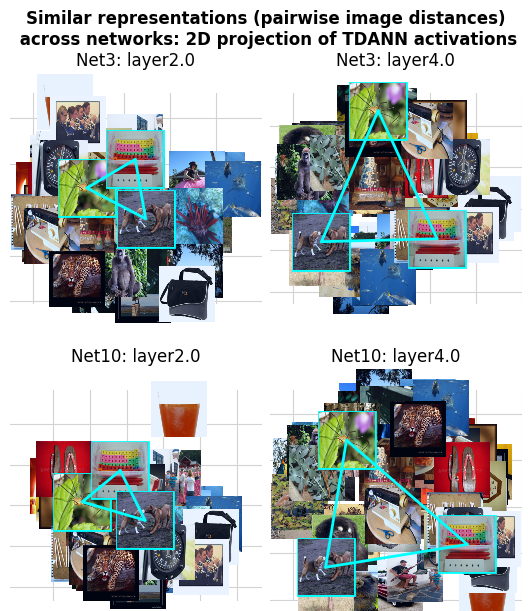

In [16]:
ref_imgs = [5,19,47]
print(ref_imgs)
max_images=50
people = [8,14,15,16,40]
input_images = inputs[spatial_key][:max_images]

exclude_people = False
if exclude_people:
    input_images = [input_images[i] for i in range(max_images) if i not in people]
    filt_coords_a = [coords_a[i] for i in range(max_images) if i not in people]
    filt_coords_b = [coords_b[i] for i in range(max_images) if i not in people]
    filt_coords_c = [coords_c[i] for i in range(max_images) if i not in people]
    filt_coords_d = [coords_d[i] for i in range(max_images) if i not in people]
    filename = 'tdann_mds_no_people.png'
    max_images = len(input_images)
    ref_imgs = [img_ind - sum(np.array(people) < img_ind) for img_ind in ref_imgs]
else:
    filt_coords_a = coords_a
    filt_coords_b = coords_b
    filt_coords_c = coords_c
    filt_coords_d = coords_d
    filename = 'tdann_mds.png'

fig, axes = create_gridspec_axes(2,2,figsize=(5.2,6),layout='constrained')
plot_stimuli_on_mds(filt_coords_a[:max_images], input_images, ax=axes[0][0], zoom=0.18,
                    title=f"Net{net1}: {layer1}", ref_imgs=ref_imgs, frame_color='aqua')
plot_stimuli_on_mds(filt_coords_b[:max_images], input_images, ax=axes[1][0], zoom=0.18,
                    title=f"Net{net2}: {layer1}", ref_imgs=ref_imgs, frame_color='aqua')


plot_stimuli_on_mds(filt_coords_c[:max_images], input_images, ax=axes[0][1], zoom=0.18,
                    title=f"Net{net1}: {layer2}", ref_imgs=ref_imgs, frame_color='aqua')
plot_stimuli_on_mds(filt_coords_d[:max_images], input_images, ax=axes[1][1], zoom=0.18,
                    title=f"Net{net2}: {layer2}", ref_imgs=ref_imgs, frame_color='aqua')

fig.suptitle('Similar representations (pairwise image distances)\n across networks: 2D projection of TDANN activations',
            fontweight="bold")

plt.savefig(os.path.join(repo_root, 'figures', 'figure1', 'panels', filename), 
    dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()

47


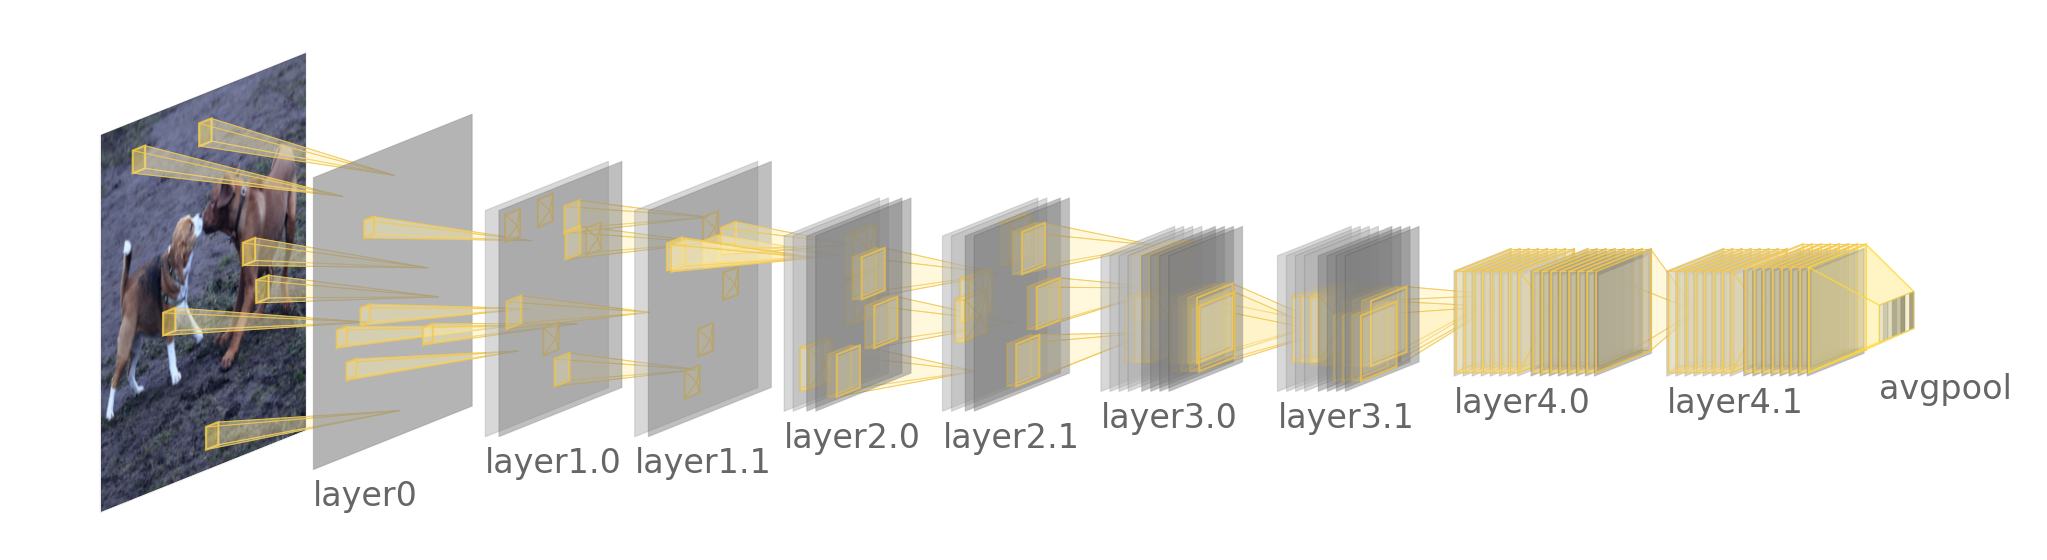

In [17]:
# What follows generates the convolutional neural net diagram used in Figure 1A.
# It's mostly genAI slop, but it creates a nice looking figure (at least in my opinion). It's
# largely independent from the above code, except that it needs some input images to illustrate
# before the input layer. This is provided by the "input" dictionary, loaded above.
from matplotlib.patches import Polygon
from matplotlib.patches import Polygon
from matplotlib.transforms import Affine2D

W_ADJ = 0.8 # a width adjustment hack

def y_for_centered_pane(y_center, h):
    """Given a global centerline y_center, return y (bottom-left) so pane is vertically centered."""
    return y_center - 0.5 * h


def pane_geometry(w, shear):
    # the *actual* x-span used to draw something of nominal width w
    w_drawn = W_ADJ*w / np.sqrt(2.0 + shear**2)
    s_drawn = shear * w_drawn
    return w_drawn, s_drawn

def parallelogram(x, y, w, h, shear=0.35):
    """4 points for a tilted pane (parallelogram)."""
    k = shear

    # choose x-span so that sqrt(wx^2 + (k*wx)^2) == w
    wx = W_ADJ*w / np.sqrt(2.0 + k*k)

    s = k * wx
    return np.array([
        [x,     y],
        [x+wx,   y+s],
        [x+wx, y+h+s],
        [x,   y+h],
    ], float)

def add_poly(ax, pts, face, edge=(0,0,0,0.15), lw=1.0, z=1):
    ax.add_patch(Polygon(pts, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, zorder=z))

def add_stack(ax, x, y, w, h, n=8, dx=0.10, dy=0, shear=0.35,
              face=(0.55,0.55,0.55,0.18), edge=(0,0,0,0.10), lw=0.9, zbase=2):
    """Stack of translucent panes to suggest channel depth."""
    for k in range(n):
        pts = parallelogram(x + k*dx, y + k*dy, w, h, shear=shear)
        add_poly(ax, pts, face=face, edge=edge, lw=lw, z=zbase + k*0.01)

def add_spotlight(ax, cx, cy, size, shear=0.35,
                  core=(1.0, 0.85, 0.20, 0.35),
                  outline=(1.0, 0.85, 0.20, 0.7),
                  z=30):
    """
    Spotlight whose (cx,cy) is intended to be the centroid on the sheared plane.
    Corrects both:
      - x half-width (because parallelogram foreshortens internally)
      - y centroid shift (+shear*wx/2)
    """

    def wx_of(w):
        # must match your parallelogram's internal foreshortening
        return W_ADJ*w / np.sqrt(2.0 + shear**2)

    def bl_xy(cx, cy, w, h):
        wx = wx_of(w)
        # centroid correction for y-shear uses the DRAWN width wx
        x0 = cx - wx/2
        y0 = cy - h/2 - (shear * wx)/2
        return x0, y0
        
    x0, y0 = bl_xy(cx, cy, size, size)
    pts_outline = parallelogram(x0, y0, size, size, shear=shear)
    add_poly(ax, pts_outline, face=(0,0,0,0), edge=outline, lw=1.6, z=z + 0.01)

    # --- inner core ---
    core_size = size * 0.9
    x0, y0 = bl_xy(cx, cy, core_size, core_size)
    pts_core = parallelogram(x0, y0, core_size, core_size, shear=shear)
    add_poly(ax, pts_core, face=core, edge=(0,0,0,0), lw=0, z=z + 0.01)


def pane_point(x, y, w_eff, h, u_bl, v_bl, shear, size):
    # spotlight footprint in data coords (consistent with your y-shear square logic)
    wK = W_ADJ*size / np.sqrt(2.0 + shear**2)
    hK = size

    u_c = u_bl + 0.5 * (wK / w_eff)
    v_c = v_bl + 0.5 * (hK / h)

    s = shear * w_eff
    X = x + u_c * w_eff
    Y = y + u_c * s + v_c * h
    return X, Y

def sample_uv_inside_pane(rng, w_eff, h, shear, size, margin_u=0.02, margin_v=0.02):
    """
    Sample (u_bl, v_bl) so that a spotlight of given `size` fits inside pane.
    u_bl, v_bl are bottom-left fractions in pane coordinates.
    """
    wK = W_ADJ*size / np.sqrt(2.0 + shear**2)  # consistent with your foreshortening choice
    hK = size

    du = wK / w_eff
    dv = hK / h

    u_min = margin_u
    v_min = margin_v
    u_max = 1.0 - du - margin_u
    v_max = 1.0 - dv - margin_v

    # if pane is too small, clamp
    u_max = max(u_min, u_max)
    v_max = max(v_min, v_max)

    u_bl = rng.uniform(u_min, u_max)
    v_bl = rng.uniform(v_min, v_max)
    return u_bl, v_bl

def spotlight_corners_on_pane(x, y, w_eff, h, shear, u_bl, v_bl, size):
    """
    Return 4 corners (BL, BR, TR, TL) of the spotlight parallelogram
    that sits on the pane at (x,y) with drawn width w_eff and height h.

    u_bl, v_bl are bottom-left fractions in pane coordinates.
    size is the same `size` you pass to add_spotlight.
    """

    # kernel footprint (drawn x-span) consistent with your conventions
    wK = W_ADJ*size / np.sqrt(2.0 + shear**2)
    hK = size

    # Shear height over that x-span
    sK = shear * wK

    # Bottom-left of spotlight in data coords on the pane
    # (this is consistent with how pane_point maps u,v)
    X0 = x + u_bl * w_eff
    Y0 = y + u_bl * (shear * w_eff) + v_bl * h

    # Corners of the sheared square (same form as parallelogram)
    BL = np.array([X0,       Y0],       float)
    BR = np.array([X0 + wK,  Y0 + sK],  float)
    TR = np.array([X0 + wK,  Y0 + hK + sK], float)
    TL = np.array([X0,       Y0 + hK],  float)

    return np.stack([BL, BR, TR, TL], axis=0)

from matplotlib.patches import Polygon

def add_frustum(ax, src_corners, dst_corners,
                face=(1.0, 0.85, 0.20, 0.35),
                edge=(1.0, 0.85, 0.20, 0.7),
                lw=0.8,
                z=10,
                draw_caps=False):
    """
    Draw 4 side faces connecting src (BL,BR,TR,TL) to dst (BL,BR,TR,TL).
    Optionally draw faint caps (top/bottom).
    """
    # side faces: connect corresponding edges
    # BL->BR, BR->TR, TR->TL, TL->BL
    idx = [(0,1), (1,2), (2,3), (3,0)]
    for a, b in idx:
        quad = np.stack([src_corners[a], src_corners[b], dst_corners[b], dst_corners[a]], axis=0)
        ax.add_patch(Polygon(quad, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, zorder=z))

    if draw_caps:
        ax.add_patch(Polygon(src_corners, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, zorder=z-0.1))
        ax.add_patch(Polygon(dst_corners, closed=True, facecolor=face, edgecolor=edge, linewidth=lw, zorder=z+0.1))

def add_image_pane(ax, img, x, y, w, h, shear=0.35,
                   edge=(0,0,0,0.08), lw=1.2, z=1,
                   interpolation="bilinear"):
    """
    Draw an RGB image onto the same sheared parallelogram geometry you use for panes.

    img: (H,W,3) uint8 or float in [0,1]
    x,y: bottom-left of pane in data coords
    w,h: nominal pane size (same convention as parallelogram())
    shear: your shear k
    Returns: (w_eff, pts, poly_patch) where w_eff is the drawn x-span.
    """
    img = np.asarray(img)
    if img.dtype.kind in "ui":
        img = img.astype(np.float32) / 255.0

    # --- must match parallelogram() internal width ---
    w_eff = W_ADJ*w / np.sqrt(2.0 + shear**2)   # drawn x-span (your wx)
    s = shear * w_eff                     # shear height over full width

    # Parallelogram vertices (for clipping + outline)
    pts = np.array([
        [x,       y],
        [x+w_eff, y+s],
        [x+w_eff, y+h+s],
        [x,       y+h],
    ], float)

    # Clip patch (also used for outline)
    poly = Polygon(pts, closed=True, facecolor="none", edgecolor=edge,
                   linewidth=lw, zorder=z+0.02)
    ax.add_patch(poly)

    # Map unit square (u,v)∈[0,1]^2 to data:
    # X = x + u*w_eff
    # Y = y + u*s + v*h
    T = Affine2D.from_values(
        w_eff, s,
        0.0,   h,
        x,     y
    )

    im = ax.imshow(
        img,
        extent=(0, 1, 0, 1),              # unit square
        transform=T + ax.transData,       # shear+scale+translate into data coords
        interpolation=interpolation,
        zorder=z
    )
    im.set_clip_path(poly)

    return w_eff, pts, poly

def add_input_image_layer(ax, img, x, y, w, h, shear,
                          rng, n_spotlights=1, k_rel=0.06,
                          margin_u=0.03, margin_v=0.03,
                          zbase=1):
    """
    Draw the image on a pane and place n_spotlights on it.
    Returns last_spotlights dict compatible with add_block chaining.
    """
    w_eff, pts, poly = add_image_pane(
        ax, img, x, y, w, h, shear=shear,
        edge=(0,0,0,0.08), lw=1.2, z=zbase
    )

    k_lin = k_rel * h  # spotlight size in data units, same convention as elsewhere

    last = {"u_bl": [], "v_bl": [], "xk": [], "yk": [],
            "w_eff": [], "h": [], "k_size": [], "corners": []}

    for s in range(n_spotlights):
        u_bl, v_bl = sample_uv_inside_pane(
            rng, w_eff=w_eff, h=h, shear=shear, size=k_lin,
            margin_u=margin_u, margin_v=margin_v
        )

        cx, cy = pane_point(x, y, w_eff, h, u_bl=u_bl, v_bl=v_bl, shear=shear, size=k_lin)
        add_spotlight(ax, cx, cy, size=k_lin, shear=shear, z=zbase + 0.5)

        corners = spotlight_corners_on_pane(x, y, w_eff, h, shear, u_bl, v_bl, k_lin)

        last["u_bl"].append(u_bl)
        last["v_bl"].append(v_bl)
        last["xk"].append(x)
        last["yk"].append(y)
        last["w_eff"].append(w_eff)
        last["h"].append(h)
        last["k_size"].append(k_lin)
        last["corners"].append(corners)

    return last

def add_input_conv(ax, x, y, w, h, shear, depth_n, dx, dy,
                   face=(0.6,0.6,0.6,0.5),
                   edge=(0,0,0,0.10),
                   rng=None, n_spotlights=1, k_rel=0.06,
                   zbase=2,
                   spotlight_face=(1.00, 0.94, 0.70, 0.25),
                   spotlight_edge=(0.95, 0.78, 0.30, 0.70),
                   last_spotlights=None):   # <-- NEW
    if rng is None:
        rng = np.random.default_rng()

    w_eff = W_ADJ*w / np.sqrt(2.0 + shear**2)
    k_lin = k_rel * h

    # --- NEW: project from previous layer (image slab) into the *first* pane of this stack ---
    if last_spotlights is not None:
        n_prev = len(last_spotlights["corners"])
        for s in range(max(n_prev, n_spotlights)):
            src_c = np.asarray(last_spotlights["corners"][s])

            # apex point on this pane, using the SAME u,v fractions
            u0 = last_spotlights["u_bl"][s]
            v0 = last_spotlights["v_bl"][s]
            apex_x, apex_y = pane_point(x, y, w_eff, h, u0, v0, shear, k_lin)
            dst_c = np.repeat(np.array([[apex_x, apex_y]]), 4, axis=0)

            add_frustum(ax, src_c, dst_c,
                        face=spotlight_face, edge=spotlight_edge,
                        lw=0.7, z=zbase-0.1, draw_caps=False)

    # draw the conv stack
    add_stack(ax, x, y, w, h, n=depth_n, dx=dx, dy=dy, shear=shear,
              face=face, edge=edge, zbase=zbase)

    last = {"u_bl": [], "v_bl": [], "xk": [], "yk": [],
            "w_eff": [], "h": [], "k_size": [], "corners": []}

    for s in range(n_spotlights):
        u_bl, v_bl = sample_uv_inside_pane(rng, w_eff, h, shear, size=k_lin,
                                           margin_u=0.03, margin_v=0.03)

        for k in range(depth_n):
            xk = x + k*dx
            yk = y + k*dy
            cx, cy = pane_point(xk, yk, w_eff, h, u_bl, v_bl, shear, k_lin)
            add_spotlight(ax, cx, cy, size=k_lin, shear=shear,
                          z=zbase + k*0.01,
                          core=spotlight_face, outline=spotlight_edge)

        xk_last = x + (depth_n - 1)*dx
        yk_last = y + (depth_n - 1)*dy
        corners = spotlight_corners_on_pane(xk_last, yk_last, w_eff, h, shear, u_bl, v_bl, k_lin)

        last["u_bl"].append(u_bl)
        last["v_bl"].append(v_bl)
        last["xk"].append(xk_last)
        last["yk"].append(yk_last)
        last["w_eff"].append(w_eff)
        last["h"].append(h)
        last["k_size"].append(k_lin)
        last["corners"].append(corners)

    x_out = x + depth_n*dx
    return x_out, last


def add_block(ax, x, y, w, h, shear, depth_n, dx, dy, conv_gap, stage_idx,
              conv1=(0.70,0.70,0.70,0.5), conv2=(0.50,0.50,0.50,0.5),
              edge=(0,0,0,0.10), k_rel=0.05, k_area_comp=2.0, 
              rng=None, n_spotlights=1, spotlight_size=None,
              final_stage=False, last_spotlights=None,
              spotlight_face=(1.00, 0.94, 0.70, 0.25),
              spotlight_edge=(0.95, 0.78, 0.30, 0.70)):
    """
    Draw a single ResNet BasicBlock (2 conv panes) with a few kernel spotlights.
    Returns new x after the block.
    """

    if rng is None:
        rng = np.random.default_rng()

    w_eff = W_ADJ*w / np.sqrt(2.0 + shear**2)
    s = shear*w_eff

    # spotlight locations, relative to top left of pane

    # Kernel compensation: double kernel *area* per stage -> linear scale sqrt(2)^stage
    #k_lin = (k_rel * h) * (np.sqrt(k_area_comp)) ** stage_idx
    k_lin = k_rel*h * (np.sqrt(k_area_comp)) ** (2*(stage_idx+1))
    size_src = k_lin
    size_dst = k_lin

    spotlights = {'u_bl': [], 'v_bl': [], 'xk': [], 'yk': [], 'k_size': []}
    if last_spotlights is not None:
        for s in range(len(last_spotlights['xk'])):
            xk0 = last_spotlights['xk'][s]
            yk0 = last_spotlights['yk'][s]
            w_eff0 = last_spotlights['w_eff'][s]
            h0     = last_spotlights['h'][s]
            k0     = last_spotlights['k_size'][s]
            u0     = last_spotlights['u_bl'][s]
            v0     = last_spotlights['v_bl'][s]
            src_c = spotlight_corners_on_pane(xk0, yk0, w_eff0, h0, shear, u0, v0, k0)
            dst_c = spotlight_corners_on_pane(x, y, w_eff, h, shear, 0, 0, size_dst)
            apex_x, apex_y = pane_point(x, y, w_eff, h, u_bl=u0, v_bl=v0, shear=shear, size=size_dst)
            dst_c = np.repeat(np.array([[apex_x, apex_y]]), 4, axis=0)            
            add_frustum(ax, src_c, dst_c,
                        face=spotlight_face,
                        edge=spotlight_edge,
                        lw=0.7,
                        z=2+stage_idx,
                        draw_caps=False)
    # conv1 (lighter glass)
    add_stack(ax, x, y, w, h, n=depth_n, dx=dx, dy=dy, shear=shear, face=conv1, edge=edge, zbase=2+stage_idx)
    for s in range(n_spotlights):
        u_bl, v_bl = sample_uv_inside_pane(rng, w_eff, h, shear, size=k_lin,
                                        margin_u=0.03, margin_v=0.03)
        for k in range(depth_n):
            xk = x + k*dx
            yk = y + k*dy
            cx, cy = pane_point(xk, yk, w_eff, h, u_bl=u_bl, v_bl=v_bl, shear=shear, size=k_lin)
            add_spotlight(ax, cx, cy, size=k_lin, shear=shear, z=2+stage_idx-0.01+k*0.01,
                core=spotlight_face, outline=spotlight_edge)
            if k > 0:
                xk0 = x + (k-1)*dx
                yk0 = y + (k-1)*dy
                src_c = spotlight_corners_on_pane(xk0,  yk0,  w_eff, h, shear, u_bl, v_bl, k_lin)
                dst_c = spotlight_corners_on_pane(xk, yk, w_eff, h, shear, u_bl, v_bl, k_lin)
                add_frustum(ax, src_c, dst_c,
                        face=spotlight_face,
                        edge=spotlight_edge,
                        lw=0.7,
                        z=2+stage_idx+k*0.01,
                        draw_caps=False)

            if k + 1 == depth_n:
                spotlights['u_bl'].append(u_bl)
                spotlights['v_bl'].append(v_bl)
                spotlights['xk'].append(xk)
                spotlights['yk'].append(yk)
                spotlights['k_size'].append(k_lin)  
            

    #x2 = x + conv_gap + 0.20*w
    x2 = x + depth_n*dx + conv_gap
    last_spotlights = spotlights

    # conv2 (darker glass)
    add_stack(ax, x2, y, w, h, n=depth_n, dx=dx, dy=dy, shear=shear, face=conv2, edge=edge, zbase=3+stage_idx)
    if final_stage:
        k_lin=h
    size_src = k_lin
    size_dst = k_lin

    spotlights = {'u_bl': [], 'v_bl': [], 'xk': [], 'yk': [], 
        'h': [], 'w_eff': [], 'k_size': [], 'corners': []}
    for s in range(n_spotlights):
        u_bl, v_bl = sample_uv_inside_pane(rng, w_eff, h, shear, size=k_lin,
                                        margin_u=0.03, margin_v=0.03)
        for k in range(depth_n):
            xk = x2 + k*dx
            yk = y + k*dy
            cx, cy = pane_point(xk, yk, w_eff, h, u_bl=u_bl, v_bl=v_bl, shear=shear, size=k_lin)
            add_spotlight(ax, cx, cy, size=k_lin, shear=shear, z=3+stage_idx-0.01+k*0.01,
                core=spotlight_face, outline=spotlight_edge)

            if k == 0:
                xk0 = last_spotlights['xk'][s]
                yk0 = last_spotlights['yk'][s]
                src_c = spotlight_corners_on_pane(xk0,  yk0,  w_eff, h, shear, 
                    last_spotlights['u_bl'][s], last_spotlights['v_bl'][s], last_spotlights['k_size'][s])
                apex = src_c.mean(axis=0)   # [X, Y]
                apex = apex + np.array([conv_gap,0])
                dst_c = np.repeat(apex[None, :], 4, axis=0)
            
            else:
                xk0 = x2 + (k-1)*dx
                yk0 = y + (k-1)*dy
                src_c = spotlight_corners_on_pane(xk0,  yk0,  w_eff, h, shear, u_bl, v_bl, size_src)
                dst_c = spotlight_corners_on_pane(xk, yk, w_eff, h, shear, u_bl, v_bl, size_dst)

            add_frustum(ax, src_c, dst_c,
                        face=spotlight_face,
                        edge=spotlight_edge,
                        lw=0.7,
                        z=3+stage_idx+k*0.01-0.01,
                        draw_caps=False)

            if k + 1 == depth_n:
                spotlights['u_bl'].append(u_bl)
                spotlights['v_bl'].append(v_bl)
                spotlights['xk'].append(xk)
                spotlights['yk'].append(yk)
                spotlights['h'].append(h)
                spotlights['w_eff'].append(w_eff)
                spotlights['k_size'].append(k_lin)  
                spotlights['corners'].append(
                    spotlight_corners_on_pane(xk, yk, w_eff, h, shear, u_bl, v_bl, k_lin))

    return x2, spotlights  # end of block, last spotlights

def add_avgpool_grid(ax, x, y, w, h, shear,
                     ncols=8, rng=None,
                     face_alpha=0.85,
                     edge=(0,0,0,0.25),
                     z=50):
    """
    Draw a 1 x ncols grid as a small pane (avgpool icon).
    Returns corners of the whole grid pane (for frustum destination).
    """
    if rng is None:
        rng = np.random.default_rng()

    # draw the overall pane outline (sheared)
    pts = parallelogram(x, y, w, h, shear=shear)
    add_poly(ax, pts, face=(1,1,1,0), edge=edge, lw=1.0, z=z)

    # compute drawn width used by parallelogram so cell boundaries line up
    wx = W_ADJ*w / np.sqrt(2.0 + shear**2)
    s = shear * wx

    # draw individual cells
    for j in range(ncols):
        frac0 = j / ncols
        frac1 = (j+1) / ncols

        x0 = x + frac0 * wx
        x1 = x + frac1 * wx

        # each cell is a mini parallelogram strip
        BL = np.array([x0, y + frac0 * s])
        BR = np.array([x1, y + frac1 * s])
        TR = BR + np.array([0, h])
        TL = BL + np.array([0, h])

        shade = rng.uniform(0.25, 0.95)
        add_poly(ax, np.stack([BL, BR, TR, TL], axis=0),
                 face=(shade, shade, shade, face_alpha),
                 edge=(0,0,0,0.15), lw=0.6, z=z+0.01)

    # Return the overall corners (BL, BR, TR, TL) in same order as spotlight_corners_on_pane
    # For parallelogram(): [x,y], [x+wx,y+s], [x+wx,y+h+s], [x,y+h]
    BL = np.array([x, y], float)
    BR = np.array([x+wx, y+s], float)
    TR = np.array([x+wx, y+h+s], float)
    TL = np.array([x, y+h], float)
    return np.stack([BL, BR, TR, TL], axis=0)

def stage_nominal_width(w, h, shear, depth_n, dx, conv_gap, nblocks, block_gap):
    """
    Predict stage width in *x-axis data units* based on how add_block advances x.
    This matches your add_block return: x2 + 0.55*w
    """
    # per block:
    # x2 = x + depth_n*dx + conv_gap
    # return x2 + 0.55*w
    # then you do x += block_gap outside
    per_block = (depth_n * dx + conv_gap + 0.55 * w) + block_gap
    return nblocks * per_block

def make_resnet18_demo(out_png, out_svg,
                       shear=0.4,
                       base_wh=(5.0, 5.0),
                       shrink_area=0.5,
                       stages=(2,2,2,2),          # ResNet-18 basic blocks per stage
                       depth_counts=(1, 2, 4, 8),  # fake channel depth stacks
                       #depth_counts=(64, 128, 256, 512),  # real chanel depth stacks
                       #depth_counts=(1,1,1,1),
                       stage_gap=0.2,
                       block_gap=2,
                       stack_dx=0.2,
                       stack_dy=0,
                       conv_gap=0.5,
                       k_rel = 0.06,
                       fontsize=24,
                       seed=1,
                       img_rgb=None):
    """
    Demo illustration for ResNet-18:
    - 4 stages, 2 basic blocks each
    - pane surface area shrinks by shrink_area per stage (your visualization rule)
    - kernels compensate by doubling area per stage (spotlight squares)
    - conv1 and conv2 shown with different glass shades
    """
    fig, ax = plt.subplots(figsize=(14, 4.8))
    ax.set_aspect("equal")
    ax.axis("off")

    x = 0.8
    y_center = 4.0
    w, h = base_wh

    # ---- compute widths for all stages with shrinkage applied ----
    '''
    w_i, h_i = base_wh
    stage_widths = []
    for si, nblocks in enumerate(stages):
        if si > 0:
            s = np.sqrt(shrink_area)
            w_i *= s
            h_i *= s
        stage_widths.append(
            stage_nominal_width(w_i, h_i, shear,
                                depth_counts[si], stack_dx, conv_gap,
                                nblocks, block_gap)
        )

    # Choose a constant center-to-center spacing.
    # A good default is "max stage width + some margin":
    D = max(stage_widths) * 1.15   # tweak 1.05..1.30 to taste

    # Compute gaps so centers are evenly spaced:
    stage_gaps = []
    for i in range(len(stage_widths)-1):
        g = D - 0.5*stage_widths[i] - 0.5*stage_widths[i+1]
        stage_gaps.append(max(0.0, g))  # clamp so it never goes negative
    stage_gaps.append(0.0)  # no gap after last stage

    '''
    # Input slab placeholder (tilted pane)

    rng = np.random.default_rng(seed)
    last_spotlights=None

    if img_rgb is None:
        input_face = (0.20, 0.45, 0.85, 0.18)
        slab_w = w * 1/shrink_area
        slab_h = h * 1/shrink_area
        y_slab = y_for_centered_pane(y_center,slab_h)
        add_poly(ax, parallelogram(x-0.8, y_slab, slab_w, slab_h, shear=shear),
                face=input_face, edge=(0,0,0,0.08), lw=1.2, z=1)

        x += 2*block_gap + stage_gap
    else:
        slab_w = w * (1 / shrink_area)
        slab_h = h * (1 / shrink_area)
        y_slab = y_for_centered_pane(y_center, slab_h)

        last_spotlights = add_input_image_layer(
            ax, img_rgb,
            x=x-0.8, y=y_slab,
            w=slab_w, h=slab_h,
            shear=shear,
            rng=rng,
            n_spotlights=6,   # or more
            k_rel=k_rel,
            zbase=1
        )

        #ax.text(x-0.8, 
        #        y_slab+slab_h+2, f"{int(img_rgb.shape[0])}x{int(img_rgb.shape[1])}",
        #        fontsize=24, alpha=0.6, horizontalalignment='left')
        x += conv_gap + stack_dx + block_gap + stage_gap + 0.6


    # input conv
    input_conv_scale = 1/(shrink_area)**0.5
    w_in = w * input_conv_scale
    h_in = h * input_conv_scale
    y_in = y_for_centered_pane(y_center, h_in)
    x, last_spotlights = add_input_conv(
        ax, x, y_in, w_in, h_in, shear,
        depth_n=1, dx=0, dy=0,
        face=(0.55,0.55,0.55,0.65),
        edge=(0,0,0,0.10),
        rng=rng, n_spotlights=5, k_rel=k_rel,
        zbase=2,last_spotlights=last_spotlights,
    )
    #ax.text(x + last_spotlights['w_eff'][0], 
    #        y_in+h_in+1.7, f"{int(2*56/depth_counts[0])}x{int(2*56/depth_counts[0])}\n{int(3)} feat.",
    #        fontsize=24, alpha=0.6, horizontalalignment='right')
    ax.text(x, y_in-0.8, f"layer0",
            fontsize=fontsize, alpha=0.6, horizontalalignment='left')
    x += stage_gap + conv_gap + stack_dx + block_gap + 0.5

    for si, nblocks in enumerate(stages):
        x0 = x    
        if si > 0:
            # shrink surface area linearly (keep aspect ratio)
            s = np.sqrt(shrink_area)
            w *= s
            h *= s


        for b in range(nblocks):
            xb0 = x
            y = y_for_centered_pane(y_center,h)
            if b+1 == nblocks and si+1 == len(stages):
                final_stage=True
            else:
                final_stage=False
            x, last_spotlights = add_block(ax, x, y, w, h, shear=shear,
                          depth_n=depth_counts[si],
                          dx=stack_dx, dy=stack_dy,
                          conv_gap=conv_gap,
                          stage_idx=si,
                          rng=rng, n_spotlights=4-si,
                          k_rel = k_rel,
                          #rng=rng, n_spotlights=1,
                          final_stage=final_stage,
                          last_spotlights=last_spotlights)
            x += block_gap


            #ax.text(xb0, y+h+1.6, f"{int(56/depth_counts[si])}x{int(56/depth_counts[si])}\n{int(64*depth_counts[si])} feat.",
            #            fontsize=24, alpha=0.6, horizontalalignment='left')
            ax.text(xb0, y-0.8, f"layer{si+1}.{b}",
                        fontsize=fontsize, alpha=0.6, horizontalalignment='left')

        x += stage_gap

    src = last_spotlights['corners'][0]   # final conv2 spotlight footprint

    # Place avgpool a bit to the right
    avg_gap = stage_gap
    avg_w = w * 0.60
    avg_h = h * 0.35
    y_avg = y_for_centered_pane(y_center, avg_h)

    x_avg = x + avg_gap
    dst = add_avgpool_grid(ax, x_avg, y_avg, avg_w, avg_h, shear=shear, ncols=8, rng=rng)

    # Draw frustum from spotlight footprint to avgpool pane
    add_frustum(ax, src, dst,
                face=(1.0, 0.92, 0.55, 0.30),   # sunlight-ish pale yellow
                edge=(1.0, 0.85, 0.20, 0.60),
                lw=0.9,
                z=60,
                draw_caps=False)


    ax.set_xlim(-2, x + 3.5)

    ax.text(x_avg, y-0.5, f"avgpool",
                fontsize=fontsize, alpha=0.6, horizontalalignment='left')

    max_w = y + h + shear * w
    max_shear_height = shear * max_w  # approximate
    ax.set_ylim(-1, 8 + max_shear_height + 0.5)

    plt.tight_layout(pad=0)
    #fig.set_size_inches(24,16)
    fig.set_size_inches(21,16)
    fig.savefig(out_png, dpi=300, transparent=True)
    fig.savefig(out_svg, transparent=True)
    #plt.close(fig)
    ax.autoscale_view()

    plt.show()

n = 47
print(n)
# view the input image
# remove batch dim, and move channels to the end
raw = inputs['Spatial'][n].squeeze().transpose(1, 2, 0)

# normalize image to the range [0, 1]
normed = (raw - np.min(raw)) / np.ptp(raw)
make_resnet18_demo(repo_root / "figures" / "figure1" / "panels" / "resnet18_glass_diagram.png",
                    repo_root / "figures" / "figure1" / "panels" / "resnet18_glass_diagram.svg",
                    stage_gap=0,
                    block_gap=3,
                    fontsize=24,
                    shrink_area=0.6,
                    conv_gap = 0.1,
                    #stack_dx=0.05,
                    seed=1,
                    img_rgb=normed)